# GLOP — Algorithme hybride TSPTW-D
## Documentation mathématique intégrée

Ce notebook présente **chaque composant mathématique** de l'algorithme GLOP  
immédiatement suivi du code Python qui l'implémente.

**Problème** : *Travelling Salesman Problem with Time Windows and Dynamic disruptions* (TSPTW-D)  
**Variable de décision** : permutation σ = (σ₁, …, σₙ) des n clients  
**Objectif** : minimiser τ* = temps de retour au dépôt

---


## 1. Chargement de l'instance

Une instance TSPTW-D est un graphe complet sur n+1 nœuds (dépôt + n clients).  
Chaque nœud i possède :

| Attribut | Notation | Description |
|---|---|---|
| Coordonnées | (xᵢ, yᵢ) | Position dans le plan (normalisée 0–1 × scale) |
| Ouverture | aᵢ | Heure d'ouverture de la fenêtre temporelle |
| Fermeture | bᵢ | Deadline — arrivée tardive → pénalité |
| Service | sᵢ | Durée du service sur place |

Le coût de base entre i et j est la **distance euclidienne** multipliée par `scale` :

$$c^{\text{base}}_{ij} = \text{scale} \times \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

Les **perturbations** sont des listes `{arc, t_start, t_end, alpha}` qui multiplient  
le coût de base par α pendant la fenêtre [t_start, t_end].


In [2]:
"""
Chargement d'une instance TSPTW-D en dictionnaire
==================================================
Structure retournée — prête pour l'optimisation :

instance = {
    # --- méta ---
    "n"      : int,           # nombre de clients (hors dépôt)
    "scale"  : float,
    "horizon": float,

    # --- nœuds (index 0 = dépôt, 1..n = clients) ---
    "coords"  : {i: (x, y)},  # coordonnées
    "a"       : {i: float},    # ouverture de fenêtre
    "b"       : {i: float},    # fermeture de fenêtre
    "service" : {i: float},    # temps de service

    # --- coûts de base (distance euclidienne × scale) ---
    "c_base"  : {(i,j): float},  # symétrique, i ≠ j

    # --- perturbations ---
    "perturbations": [
        {"arc": (i,j), "t_start": float, "t_end": float, "alpha": float},
        ...
    ],
}

Fonctions exposées
------------------
charger_instance(chemin)        → dict  (chargement complet)
c_ij(instance, i, j, t)        → float (coût dynamique à l'instant t)
"""

import json
import math
from pathlib import Path


# ---------------------------------------------------------------------------
# Chargement principal
# ---------------------------------------------------------------------------

def charger_instance(chemin: str | Path) -> dict:
    """
    Charge un fichier JSON généré par `generer_dataset_tsptwd`
    et retourne un dictionnaire prêt pour l'optimisation.

    Paramètre
    ---------
    chemin : chemin vers le fichier .json

    Retourne
    --------
    instance : dict avec les clés décrites en en-tête de module.
    """
    with open(chemin, encoding="utf-8") as f:
        data = json.load(f)

    n       = data["meta"]["n_clients"]
    scale   = data["meta"]["scale"]
    horizon = data["meta"]["horizon"]

    # --- nœuds : dépôt (0) + clients (1..n) --------------------------------
    coords  = {}
    a       = {}
    b       = {}
    service = {}

    d = data["depot"]
    coords[0]  = (d["x"], d["y"])
    a[0]       = d["a"]
    b[0]       = d["b"]
    service[0] = d["service"]

    for c in data["clients"]:
        i          = c["id"]          # 1..n
        coords[i]  = (c["x"], c["y"])
        a[i]       = c["a"]
        b[i]       = c["b"]
        service[i] = c["service"]

    # --- coûts de base : distance euclidienne × scale -----------------------
    noeuds = list(range(n + 1))
    c_base = {
        (i, j): round(
            math.hypot(coords[i][0] - coords[j][0],
                       coords[i][1] - coords[j][1]) * scale,
            4,
        )
        for i in noeuds
        for j in noeuds
        if i != j
    }

    # --- perturbations ------------------------------------------------------
    perturbations = [
        {
            "arc":     tuple(p["arc"]),
            "t_start": p["t_start"],
            "t_end":   p["t_end"],
            "alpha":   p["alpha"],
        }
        for p in data.get("perturbations", [])
    ]

    instance = {
        "n":             n,
        "scale":         scale,
        "horizon":       horizon,
        "coords":        coords,
        "a":             a,
        "b":             b,
        "service":       service,
        "c_base":        c_base,
        "perturbations": perturbations,
    }

    return instance


# ---------------------------------------------------------------------------
# Coût dynamique (modèle TSPTW-D du Livrable 1)
# ---------------------------------------------------------------------------

def c_ij(instance: dict, i: int, j: int, t: float) -> float:
    """
    Coût de transit dynamique de i vers j en partant à l'instant t.

        c_ij(t) = c_base[i,j] × (1 + δ_ij(t))

    δ_ij(t) = alpha - 1  si une perturbation sur (i,j) ou (j,i) est active à t
    δ_ij(t) = 0          sinon

    Paramètres
    ----------
    instance : dict retourné par charger_instance()
    i, j     : indices des nœuds (0 = dépôt)
    t        : instant de départ (minutes)

    Retourne
    --------
    Coût en minutes (float > 0).
    """
    base = instance["c_base"][(i, j)]
    for p in instance["perturbations"]:
        arc = p["arc"]
        if arc == (i, j) or arc == (j, i):   # symétrique
            if p["t_start"] <= t <= p["t_end"]:
                return base * p["alpha"]
    return base


# ---------------------------------------------------------------------------
# Propagation temporelle (utilitaire pour les algorithmes)
# ---------------------------------------------------------------------------

def evaluer_tournee(instance: dict, permutation: list[int],
                    dynamique: bool = True) -> tuple[bool, float]:
    """
    Évalue une permutation de clients et retourne (réalisable, coût_total).

    La permutation ne contient que les indices clients (1..n).
    Le dépôt (0) est ajouté automatiquement en début et fin.

        τ_{k+1} = max(τ_k, a_k) + service_k + c_ij(t_départ)

    Paramètres
    ----------
    instance    : dict retourné par charger_instance()
    permutation : liste d'indices clients, ex. [3, 1, 4, 2]
    dynamique   : si True, utilise c_ij() (coûts avec perturbations)
                  si False, utilise c_base (coûts statiques)

    Retourne
    --------
    (True,  coût)        si la tournée est réalisable
    (False, float('inf')) sinon
    """
    a       = instance["a"]
    b       = instance["b"]
    service = instance["service"]
    c_base  = instance["c_base"]

    route = [0] + list(permutation) + [0]
    t     = 0.0
    cout  = 0.0

    for k in range(len(route) - 1):
        i, j = route[k], route[k + 1]

        # Fenêtre de départ du nœud i
        if t > b[i]:
            return False, float("inf")

        # Attente éventuelle + service
        t = max(t, a[i]) + service[i]

        # Transit
        transit = c_ij(instance, i, j, t) if dynamique else c_base[(i, j)]
        cout   += transit
        t      += transit

    # Vérification retour au dépôt
    if t > b[0]:
        return False, float("inf")

    return True, round(cout, 4)


# ---------------------------------------------------------------------------
# Affichage récapitulatif
# ---------------------------------------------------------------------------

def afficher_instance(instance: dict) -> None:
    """Affiche un résumé lisible de l'instance."""
    n = instance["n"]
    print(f"Instance TSPTW-D")
    print(f"  Clients       : {n}")
    print(f"  Horizon       : {instance['horizon']} min")
    print(f"  Scale         : {instance['scale']}")
    print(f"  Perturbations : {len(instance['perturbations'])}")
    print()
    print(f"  {'Nœud':<10} {'Coords':>20}  {'[a, b]':>20}  {'service':>8}")
    print("  " + "-" * 65)
    for i in range(n + 1):
        nom  = "Dépôt" if i == 0 else f"Client {i}"
        x, y = instance["coords"][i]
        ai, bi = instance["a"][i], instance["b"][i]
        si = instance["service"][i]
        print(f"  {nom:<10} ({x:7.3f}, {y:7.3f})  [{ai:6.1f}, {bi:6.1f}]  {si:7.1f} min")

    if instance["perturbations"]:
        print()
        print(f"  {'Arc':<10} {'t_start':>10} {'t_end':>10} {'alpha':>8}")
        print("  " + "-" * 45)
        for p in instance["perturbations"]:
            print(f"  {str(p['arc']):<10} {p['t_start']:>10.1f} {p['t_end']:>10.1f} {p['alpha']:>8.2f}")


## 2. Structure de données — la classe `Ville`

`Ville` est le nœud interne de GLOP. Il encapsule les attributs du nœud  
(coordonnées en unités GLOP = coordonnées brutes × scale, fenêtre [a, b], service).  
L'index 0 est toujours le dépôt.


In [3]:
%matplotlib inline

"""
=============================================================================
Algorithme hybride GLOP pour le TSPTW-D  —  avec visualisation temps réel
=============================================================================

Problème : Travelling Salesman Problem with Time Windows and Dynamic disruptions
           (voir livrable_1_modelisation.ipynb)

Contraintes du modèle :
  - Graphe complet, coûts symétriques c_ij(t) = c_ij_base * (1 + delta_ij(t))
  - Fenêtres temporelles [a_i, b_i] avec attente autorisée
  - Temps de service s_i
  - Perturbations : liste de dicts { 'arc':(i,j), 't_debut':float,
                                      't_fin':float,  'alpha':float }

Variable de décision : permutation sigma = (0, sigma_1, ..., sigma_n, 0)
Fonction objectif    : minimiser tau_0^retour (temps de retour au dépôt)

=============================================================================
Architecture GLOP
=============================================================================

G — Algorithme Génétique  (population)
    Initialisation greedy + aléatoire, sélection par tournoi,
    croisement OX, mutation swap / 2-opt local.

L — Local Search           (amélioration)
    2-opt et Or-opt avec évaluation dynamique des coûts c_ij(t).

O — Optimization           (renforcement élite)
    DP sur fenêtres glissantes de taille dp_window sur l'élite.

P — Perturbation           (diversification)
    Double-Bridge (4-opt non-séquentiel) sur individus stagnants.

Visualisation : 3 panneaux matplotlib mis à jour en temps réel
    - Carte de la meilleure tournée courante
    - Courbe de convergence (meilleur / moyen / pire)
    - Diversité de la population (boxplot + strip)

=============================================================================
Exemple d'utilisation
=============================================================================

    from glop_tsptwd import charger_villes_depuis_split, lancer_visualisation

    villes = charger_villes_depuis_split(chunk_size=200, source="tsp")
    lancer_visualisation(
        villes,
        perturbations   = [],
        taille_pop      = 80,
        n_generations   = 20000,
        taux_croisement = 0.85,
        taux_mutation   = 0.12,
        taux_elitisme   = 0.10,
        patience        = 350,
    )
=============================================================================
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import csv
import math
import os
import random
import itertools
import time
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import matplotlib, os as _os

# Sélection automatique du backend interactif disponible.
# Priorité : TkAgg → Qt5Agg → wxAgg → Agg (headless/CI).
# Forçage possible via : MPLBACKEND=Qt5Agg python glop_tsptwd.py
if not _os.environ.get("MPLBACKEND"):
    for _backend in ("TkAgg", "Qt5Agg", "wxAgg", "Agg"):
        try:
            matplotlib.use(_backend)
            break
        except Exception:
            continue

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D



# =============================================================================
# STRUCTURES DE DONNÉES
# =============================================================================

class Ville:
    """Nœud du graphe TSPTW-D (dépôt = index 0, clients = index 1..n)."""

    def __init__(
        self,
        nom: str,
        x: float,
        y: float,
        fenetre: Tuple[float, float] = (0, float("inf")),
        service: float = 0.0,
    ):
        self.nom     = nom
        self.x       = x
        self.y       = y
        self.a       = fenetre[0]   # heure d'ouverture
        self.b       = fenetre[1]   # heure de fermeture (deadline)
        self.service = service      # temps de service s_i (minutes)

    def __repr__(self):
        return self.nom




## 3. Matrice de coûts et coût dynamique c_ij(t)

### 3.1 Coût de base

La matrice `matrice_base[i][j]` est calculée **une seule fois** avant la boucle  
(appel à `construire_matrice`). Elle stocke la distance euclidienne entre villes :

$$c^{\text{base}}_{ij} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

*(les coordonnées sont déjà en unités GLOP = brut × scale, donc pas de second ×scale ici)*

### 3.2 Coût dynamique avec perturbations

Le coût réel dépend de l'heure de départ t. Si une perturbation est active sur  
l'arc (i,j) ou (j,i) à l'instant t, le coût est multiplié par α > 1 :

$$c_{ij}(t) = c^{\text{base}}_{ij} \times \begin{cases} \alpha & \text{si } \exists\, p : p.\text{arc} \in \{(i,j),(j,i)\} \text{ et } t \in [p.t_{\text{debut}}, p.t_{\text{fin}}] \\ 1 & \text{sinon} \end{cases}$$

`cout_dynamique()` est appelée à chaque évaluation de tournée pour chaque arc.


In [4]:
# =============================================================================
# MATRICE DE COÛTS ET COÛTS DYNAMIQUES
# =============================================================================

def duree_trajet_base(a: Ville, b: Ville) -> float:
    """Coût nominal (distance euclidienne entre deux villes)."""
    return math.sqrt((a.x - b.x) ** 2 + (a.y - b.y) ** 2)


def construire_matrice(villes: List[Ville]) -> List[List[float]]:
    """Matrice n×n des coûts nominaux (statiques)."""
    n = len(villes)
    return [
        [duree_trajet_base(villes[i], villes[j]) for j in range(n)]
        for i in range(n)
    ]


def cout_dynamique(
    i: int,
    j: int,
    t: float,
    matrice_base: List[List[float]],
    perturbations: List[dict],
) -> float:
    """
    Coût de transit de la ville i vers la ville j en partant au temps t.

        c_ij(t) = c_base[i][j] * (1 + delta_ij(t))

    Paramètres
    ----------
    i, j          : indices des villes
    t             : instant de départ de la ville i
    matrice_base  : matrice des coûts nominaux (liste de listes)
    perturbations : liste de dicts
                    { 'arc': (i,j), 't_debut': float, 't_fin': float, 'alpha': float }
                    L'arc est symétrique : (i,j) == (j,i)
    """
    base = matrice_base[i][j]
    for p in perturbations:
        arc = p["arc"]
        if (arc == (i, j) or arc == (j, i)) and p["t_debut"] <= t <= p["t_fin"]:
            return base * p["alpha"]
    return base




## 4. Évaluation d'une tournée — `evaluer_tournee` et `fitness`

### 4.1 Propagation temporelle

La tournée est la séquence 0 → σ₁ → σ₂ → ··· → σₙ → 0.  
L'horloge démarre à τ₀ = 0. À chaque étape k :

$$\tau_{k+1} = \max(\tau_k,\ a_{\sigma_k}) + s_{\sigma_k} + c_{\sigma_k,\,\sigma_{k+1}}(\tau_k)$$

- **max(τ_k, a_i)** : on attend l'ouverture si on est en avance  
- **+ s_i** : temps de service  
- **+ c_ij(τ)** : transit dynamique avec perturbation éventuelle

### 4.2 Gestion des retards — pénalité "lendemain"

Si τ_k > b_i (deadline dépassée), au lieu de rejeter la tournée avec ∞,  
on considère qu'on reporte au **lendemain** :

$$\tau \leftarrow a_i + 1440 \qquad \text{pénalité} \mathrel{+}= 1440 \text{ min}$$

Cela permet à l'algorithme génétique de **comparer et améliorer** des solutions  
infaisables plutôt que de les traiter toutes de façon identique (∞).

### 4.3 Fonction objectif

$$f(\sigma) = \tau^* + \text{pénalité\_cumulée}$$

`fitness()` retourne toujours un nombre fini ∈ ℝ⁺. Une solution sans retard  
(`nb_retards = 0`) est dite **faisable** et domine toute solution avec retard  
(car PENALITE_JOUR = 1440 >> tout coût de transit réaliste).


In [5]:
# =============================================================================
# ÉVALUATION D'UNE TOURNÉE
# =============================================================================

# Durée d'un jour de retard (pénalité "attendre le lendemain")
PENALITE_JOUR = 1440.0   # minutes


def evaluer_tournee(
    chromosone: List[int],
    villes: List[Ville],
    matrice_base: List[List[float]],
    perturbations: List[dict],
) -> Tuple[bool, float]:
    """
    Évalue une tournée représentée par une liste de clients (sans le dépôt).

    Le dépôt (indice 0) est ajouté au début et à la fin : 0 → chromosone → 0.

    Gestion des retards
    -------------------
    Lorsque l'heure d'arrivée dépasse la deadline b_i d'un nœud, la tournée
    n'est pas immédiatement abandonnée : on considère qu'on attend le lendemain
    (report de 24 h = PENALITE_JOUR minutes) et on repart depuis l'ouverture
    a_i du jour suivant.  Une pénalité cumulée est ajoutée au coût final.

    Returns
    -------
    (faisable, coût_total)
        faisable   : True si aucun jour de retard n'a été nécessaire
        coût_total : temps total incluant les éventuelles pénalités de retard
    """
    route = [0] + list(chromosone) + [0]
    t          = 0.0
    penalite   = 0.0
    nb_retards = 0

    for k in range(len(route) - 1):
        i  = route[k]
        j  = route[k + 1]
        vi = villes[i]

        # ── Arrivée trop tardive : report au lendemain ────────────────────────
        b_i = vi.b if vi.b is not None else math.inf
        if t > b_i: 
            nb_retards += 1
            # On attend le lendemain : t repart de l'ouverture du jour suivant
            t         = vi.a + PENALITE_JOUR
            penalite += PENALITE_JOUR

        # ── Attente éventuelle (arrivée avant ouverture) + service ────────────
        t = max(t, vi.a) + vi.service

        # ── Transit dynamique ─────────────────────────────────────────────────
        t += cout_dynamique(i, j, t, matrice_base, perturbations)

    # ── Retour au dépôt : même logique de pénalité ───────────────────────────
    depot = villes[0]
    if t > depot.b:
        nb_retards += 1
        t          = depot.a + PENALITE_JOUR
        penalite  += PENALITE_JOUR

    faisable = (nb_retards == 0)
    return faisable, round(t + penalite, 4)


def fitness(
    chromosone: List[int],
    villes: List[Ville],
    matrice_base: List[List[float]],
    perturbations: List[dict],
) -> float:
    """Score fitness = coût total de la tournée (math.inf si infaisable)."""
    _, cout = evaluer_tournee(chromosone, villes, matrice_base, perturbations)
    return cout




## 5. Opérateurs génétiques

### 5.1 Croisement OX — `_croisement_ox`

Le *Order Crossover* préserve l'ordre relatif des clients. Soient P₁ et P₂ deux parents, a < b tirés uniformément :

1. Copier P₁[a:b] en position fixe dans l'enfant
2. Parcourir P₂ à partir de la position b+1 (circulaire) et insérer les gènes absents

$$E[a:b] = P_1[a:b] \qquad E[\text{reste}] = P_2 \setminus P_1[a:b] \text{ (dans l'ordre P₂)}$$

Garantit une permutation valide tout en mélangeant deux ordres parentaux.

### 5.2 Mutation swap — `_mutation_swap`

Échange deux positions i, j tirées aléatoirement. Perturbation minimale,  
préserve la plupart de la structure.

### 5.3 Mutation 2-opt — `_mutation_2opt`

Retournement d'un sous-segment [i, j]. À chaque itération on tire (i, j) et on teste :

$$\sigma' = \sigma[:i] \;+\; \sigma[i:j+1]^{-1} \;+\; \sigma[j+1:]$$

Accepté si f(σ') < f(σ) − ε. Répété `max_iter = 30` fois. Particulièrement  
efficace pour les tournées sans fenêtres serrées.

### 5.4 Or-opt — `_or_opt_individu`

Déplace un segment contigu de taille s ∈ {1, 2, 3} vers une autre position.  
Mouvement plus riche que le swap (préserve les sous-séquences locales).  
Appliqué avec probabilité 0.30 après mutation, `max_iter = 20`.

### 5.5 Double-Bridge — `_double_bridge` (Phase P)

3 coupures (a < b < c) → recomposition A|C|B|D au lieu de A|B|C|D :

$$\sigma' = \sigma[:a] \;+\; \sigma[b:c] \;+\; \sigma[a:b] \;+\; \sigma[c:]$$

Mouvement **4-opt non-séquentiel** : aucune séquence de 2-opt ne peut le défaire.  
Activé quand `sans_amelio > patience // 3` (stagnation prolongée).

### 5.6 Réoptimisation DP — `_dp_reoptimise` (Phase O)

Pour chaque fenêtre glissante de taille w (position start = 0..n-w) :

$$\text{tester toutes les } w! \text{ permutations de } \sigma[start:start+w]$$

Coût total : O(n × w!). Pour w = 4 → 24 évaluations par position.  
Appliqué sur l'élite toutes les ⌊patience/5⌋ générations.

### 5.7 Sélection par tournoi — `_selectionner_tournoi`

On tire k = 3 individus au hasard et on retourne le meilleur.  
Pression sélective contrôlée : k grand → plus élitiste, k petit → plus diversifié.

### 5.8 Initialisation — `_initialiser_population`

- **1 individu greedy** : plus proche voisin depuis le dépôt (solution de démarrage de qualité)
- **pop − 1 individus aléatoires** : diversité initiale


In [6]:
# =============================================================================
# OPÉRATEURS GÉNÉTIQUES
# =============================================================================

def _croisement_ox(
    parent1: List[int],
    parent2: List[int],
    rng: random.Random,
) -> List[int]:
    """Croisement OX (Order Crossover) — préserve l'ordre relatif des gènes."""
    n = len(parent1)
    a, b = sorted(rng.sample(range(n), 2))
    enfant: List[Optional[int]] = [None] * n
    enfant[a:b + 1] = parent1[a:b + 1]
    reste = [g for g in parent2 if g not in enfant[a:b + 1]]
    pos = [(b + 1 + k) % n for k in range(n - (b - a + 1))]
    for i, gene in zip(pos, reste):
        enfant[i] = gene
    return enfant  # type: ignore[return-value]


def _mutation_swap(chromosone: List[int], rng: random.Random) -> List[int]:
    """Échange deux gènes choisis aléatoirement."""
    fils = chromosone[:]
    i, j = rng.sample(range(len(fils)), 2)
    fils[i], fils[j] = fils[j], fils[i]
    return fils


def _mutation_2opt(
    chromosone: List[int],
    villes: List[Ville],
    matrice_base: List[List[float]],
    perturbations: List[dict],
    rng: random.Random,
    max_iter: int = 50,
) -> List[int]:
    """Amélioration 2-opt stochastique sur un individu."""
    best = chromosone[:]
    best_f = fitness(best, villes, matrice_base, perturbations)
    n = len(best)
    for _ in range(max_iter):
        i, j = sorted(rng.sample(range(n), 2))
        candidat = best[:i] + best[i:j + 1][::-1] + best[j + 1:]
        f = fitness(candidat, villes, matrice_base, perturbations)
        if f < best_f - 1e-9:
            best, best_f = candidat, f
    return best


def _or_opt_individu(
    chromosone: List[int],
    villes: List[Ville],
    matrice_base: List[List[float]],
    perturbations: List[dict],
    rng: random.Random,
    segment_sizes: Tuple[int, ...] = (1, 2, 3),
    max_iter: int = 40,
) -> List[int]:
    """Or-opt stochastique : déplace un segment de 1, 2 ou 3 clients."""
    best = chromosone[:]
    best_f = fitness(best, villes, matrice_base, perturbations)
    n = len(best)

    for _ in range(max_iter):
        seg = rng.choice(segment_sizes)
        if seg >= n:
            continue
        start = rng.randint(0, n - seg)
        segment = best[start:start + seg]
        reste = best[:start] + best[start + seg:]
        ins = rng.randint(0, len(reste))
        candidat = reste[:ins] + segment + reste[ins:]
        f = fitness(candidat, villes, matrice_base, perturbations)
        if f < best_f - 1e-9:
            best, best_f = candidat, f

    return best


def _double_bridge(chromosone: List[int], rng: random.Random) -> List[int]:
    """
    Perturbation Double-Bridge (4-opt non-séquentiel).
    Découpe la tournée en 4 segments A|B|C|D et recompose en A|C|B|D,
    ce qui échappe aux bassins d'attraction du 2-opt.
    """
    n = len(chromosone)
    if n < 4:
        fils = chromosone[:]
        rng.shuffle(fils)
        return fils
    cuts = sorted(rng.sample(range(1, n), 3))
    a, b, c = cuts
    return (
        chromosone[:a]
        + chromosone[b:c]
        + chromosone[a:b]
        + chromosone[c:]
    )


def _dp_reoptimise(
    chromosone: List[int],
    villes: List[Ville],
    matrice_base: List[List[float]],
    perturbations: List[dict],
    window: int = 5,
) -> List[int]:
    """
    Réoptimisation par énumération exhaustive sur des sous-séquences
    glissantes de longueur `window`. Pour chaque fenêtre, toutes les
    permutations sont testées et la meilleure est retenue.
    """
    best = chromosone[:]
    best_f = fitness(best, villes, matrice_base, perturbations)
    n = len(best)

    for start in range(n - window + 1):
        sub = best[start:start + window]
        prefix = best[:start]
        suffix = best[start + window:]
        for perm in itertools.permutations(sub):
            candidat = prefix + list(perm) + suffix
            f = fitness(candidat, villes, matrice_base, perturbations)
            if f < best_f - 1e-9:
                best_f = f
                best = candidat

    return best


def _selectionner_tournoi(
    population: List[List[int]],
    scores: List[float],
    k: int,
    rng: random.Random,
) -> List[int]:
    """Sélection par tournoi de taille k (retourne une copie du gagnant)."""
    indices = rng.sample(range(len(population)), k)
    gagnant = min(indices, key=lambda i: scores[i])
    return population[gagnant][:]


def _initialiser_population(
    n_clients: int,
    taille_pop: int,
    villes: List[Ville],
    matrice_base: List[List[float]],
    perturbations: List[dict],
    rng: random.Random,
) -> List[List[int]]:
    """
    Initialise la population :
    - 1 individu greedy (plus proche voisin depuis le dépôt)
    - reste : permutations aléatoires
    """
    clients = list(range(1, n_clients + 1))
    population: List[List[int]] = []

    # Individu greedy : plus proche voisin
    non_visites = clients[:]
    current = 0
    greedy: List[int] = []
    while non_visites:
        suivant = min(non_visites, key=lambda j: matrice_base[current][j])
        greedy.append(suivant)
        non_visites.remove(suivant)
        current = suivant
    population.append(greedy)

    # Reste aléatoire
    for _ in range(taille_pop - 1):
        ind = clients[:]
        rng.shuffle(ind)
        population.append(ind)

    return population




## 6. Visualisation — `_init_figure` et `_maj_affichage`

La visualisation produit **3 panneaux** mis à jour toutes les `freq_affichage` générations  
via `clear_output(wait=True)` (compatible Jupyter) :

| Panneau | Contenu |
|---|---|
| Carte (gauche) | Positions des villes + meilleure tournée courante |
| Convergence (haut droite) | Courbes best / mean / worst sur l'historique des générations |
| Diversité (bas droite) | Boxplot + strip des scores de la population courante |

`_init_figure` construit la figure une seule fois (éléments statiques).  
`_maj_affichage` met à jour uniquement les artistes dynamiques (données des lignes,  
fill_between, boxplot) — aucun redessinage complet.


In [7]:
# =============================================================================
# VISUALISATION — _init_figure
# =============================================================================

def _init_figure(villes: List[Ville]):
    """
    Crée la figure matplotlib avec 3 panneaux.
    Les éléments statiques (points des villes, axes) sont dessinés une fois.
    Retourne (fig, artistes) où artistes est un dict des objets à mettre à jour.
    """
    fig = plt.figure(figsize=(14, 6), facecolor="#f8f8f6")
    fig.suptitle(
        "Algorithme GLPO — Optimisation de tournées  |  ADEME / CesiCDP",
        fontsize=12, fontweight="bold", color="#2c2c2a", y=0.99,
    )

    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        left=0.06, right=0.97, top=0.93, bottom=0.13,
        wspace=0.45, hspace=0.50,
    )
    ax_carte  = fig.add_subplot(gs[:, 0])  # toute la colonne gauche
    ax_conv   = fig.add_subplot(gs[0, 1])  # convergence
    ax_divers = fig.add_subplot(gs[1, 1])  # diversité

    # ── Panneau carte : éléments fixes ───────────────────────────────────────
    xs = np.array([v.x for v in villes])
    ys = np.array([v.y for v in villes])
    marge = max((xs.max() - xs.min()) * 0.05, 1)

    ax_carte.set_facecolor("#eef3ee")
    ax_carte.set_xlabel("km (est-ouest)", fontsize=9, color="#5f5e5a")
    ax_carte.set_ylabel("km (nord-sud)",  fontsize=9, color="#5f5e5a")
    ax_carte.tick_params(labelsize=8, colors="#5f5e5a")
    ax_carte.set_xlim(xs.min() - marge, xs.max() + marge)
    ax_carte.set_ylim(ys.min() - marge, ys.max() + marge)

    # Points des villes (dessinés une seule fois)
    ax_carte.scatter(xs[1:], ys[1:], s=60,  color="#534AB7",
                     zorder=4, edgecolors="white", linewidths=0.8)
    ax_carte.scatter(xs[0],  ys[0],  s=180, color="#BA7517",
                     zorder=5, marker="*", edgecolors="white", linewidths=0.8)

    # Artiste de la route : seules ses données changent à chaque génération
    (ligne_route,) = ax_carte.plot([], [], "-", color="#1D9E75",
                                   linewidth=2, alpha=0.8, zorder=3)

    txt_info = fig.text(
        0.02, 0.01, "",
        fontsize=9, color="#2c2c2a",
        verticalalignment="bottom", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  alpha=0.85, edgecolor="#d3d1c7"),
    )
    titre_carte = ax_carte.set_title(
        "Génération 0", fontsize=11, color="#2c2c2a", pad=5
    )
    ax_carte.legend(
        handles=[
            Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#BA7517", markersize=12, label="Dépôt"),
            Line2D([0], [0], marker="o", color="w",
                   markerfacecolor="#534AB7", markersize=7,  label="Livraison"),
            Line2D([0], [0], color="#1D9E75", lw=2, label="Meilleure tournée"),
        ],
        fontsize=8,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        framealpha=0.85,
        edgecolor="#d3d1c7",
    )

    # ── Panneau convergence ───────────────────────────────────────────────────
    ax_conv.set_facecolor("#f8f8f6")
    ax_conv.set_title("Convergence", fontsize=10, color="#2c2c2a", pad=4)
    ax_conv.set_xlabel("Génération", fontsize=8.5, color="#5f5e5a")
    ax_conv.set_ylabel("Distance (km)", fontsize=8.5, color="#5f5e5a")
    ax_conv.tick_params(labelsize=8, colors="#5f5e5a")

    (line_best,)  = ax_conv.plot([], [], color="#0F6E56", lw=2,   label="Meilleure")
    (line_mean,)  = ax_conv.plot([], [], color="#185FA5", lw=1.2, label="Moyenne", alpha=0.75)
    (line_worst,) = ax_conv.plot([], [], color="#993C1D", lw=0.8, label="Pire",
                                 linestyle="--", alpha=0.5)
    fill_ref = [ax_conv.fill_between([], [], [], alpha=0.08, color="#185FA5")]
    ax_conv.legend(fontsize=8, loc="upper right",
                   framealpha=0.85, edgecolor="#d3d1c7")

    # ── Panneau diversité ─────────────────────────────────────────────────────
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Distance (km)", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    artistes = dict(
        ax_carte    = ax_carte,
        ax_conv     = ax_conv,
        ax_divers   = ax_divers,
        ligne_route = ligne_route,
        txt_info    = txt_info,
        titre_carte = titre_carte,
        line_best   = line_best,
        line_mean   = line_mean,
        line_worst  = line_worst,
        fill_ref    = fill_ref,   # liste mutable pour remplacer le patch fill
    )
    return fig, artistes



# =============================================================================
# VISUALISATION — _maj_affichage
# =============================================================================

def _maj_affichage(
    fig,
    artistes: dict,
    villes: List[Ville],
    generation: int,
    meilleur: List[int],
    meilleure_dur: float,
    initiale_dur: float,
    hist_best: List[float],
    hist_mean: List[float],
    hist_worst: List[float],
    population: List[List[int]],
    matrice_base: List[List[float]],
    perturbations: List[dict],
):
    ax_conv   = artistes["ax_conv"]
    ax_divers = artistes["ax_divers"]

    # ── Carte ─────────────────────────────────────────────────────────────────
    tournee = [0] + meilleur + [0]
    artistes["ligne_route"].set_data(
        [villes[i].x for i in tournee],
        [villes[i].y for i in tournee],
    )
    gain = (initiale_dur - meilleure_dur) / initiale_dur * 100 if initiale_dur > 0 else 0
    artistes["txt_info"].set_text(
        f"Score : {meilleure_dur:.1f}\nGain  : -{gain:.1f}%"
    )
    artistes["titre_carte"].set_text(
        f"Meilleure tournée — génération {generation}"
    )

    # ── Convergence ───────────────────────────────────────────────────────────
    gens = np.arange(len(hist_best))
    artistes["line_best"].set_data(gens, hist_best)
    artistes["line_mean"].set_data(gens, hist_mean)
    artistes["line_worst"].set_data(gens, hist_worst)

    artistes["fill_ref"][0].remove()
    artistes["fill_ref"][0] = ax_conv.fill_between(
        gens, hist_worst, hist_best, alpha=0.08, color="#185FA5"
    )
    ax_conv.set_xlim(0, max(len(hist_best) + 1, 10))
    ax_conv.set_ylim(min(hist_best) * 0.97, max(hist_worst) * 1.03)

    # ── Diversité (boxplot + strip) ───────────────────────────────────────────
    ax_divers.cla()
    ax_divers.set_facecolor("#f8f8f6")
    ax_divers.set_title("Diversité population", fontsize=10, color="#2c2c2a", pad=4)
    ax_divers.set_ylabel("Score fitness", fontsize=8.5, color="#5f5e5a")
    ax_divers.tick_params(labelsize=8, colors="#5f5e5a")
    ax_divers.set_xticks([])

    scores = np.array([
        fitness(c, villes, matrice_base, perturbations)
        for c in population
    ])
    scores_finis = scores[np.isfinite(scores)]
    if len(scores_finis) == 0:
        scores_finis = scores

    ax_divers.boxplot(
        scores_finis, vert=True, patch_artist=True, widths=0.45,
        boxprops     = dict(facecolor="#B5D4F4", color="#185FA5", linewidth=1.2),
        medianprops  = dict(color="#0F6E56",     linewidth=2),
        whiskerprops = dict(color="#185FA5",     linewidth=1),
        capprops     = dict(color="#185FA5",     linewidth=1.2),
        flierprops   = dict(marker="o", color="#993C1D", markersize=3, alpha=0.45),
    )
    jitter = np.random.uniform(-0.18, 0.18, len(scores_finis))
    ax_divers.scatter(1 + jitter, scores_finis,
                      alpha=0.2, s=8, color="#534AB7", zorder=2)
    ax_divers.text(
        0.97, 0.97,
        f"min  {scores_finis.min():.0f}\nmoy  {scores_finis.mean():.0f}\n"
        f"max  {scores_finis.max():.0f}\nσ    {scores_finis.std():.0f}",
        transform=ax_divers.transAxes, fontsize=8,
        color="#2c2c2a", va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  alpha=0.85, edgecolor="#d3d1c7"),
    )

    # Jupyter : pas de rafraîchissement temps réel (affichage à la fin)




## 7. Algorithme principal — `lancer_visualisation`

### Boucle principale GLOP

À chaque génération, dans l'ordre :

1. **Tri** de la population par fitness croissante
2. **Historique** : enregistrement de best/mean/worst pour les courbes
3. **Mise à jour** du meilleur global si amélioration → réinitialise `sans_amelio`
4. **Condition d'arrêt** : `sans_amelio ≥ patience` ou `gen = n_generations`
5. **Phase O** (élite) : DP sur fenêtre glissante toutes les ⌊patience/5⌋ générations
6. **Phase G** : croisement OX (prob. `taux_croisement`) ou copie par tournoi
7. **Phase L** : mutation swap ou 2-opt (prob. `taux_mutation`), puis Or-opt (prob. 0.30)
8. **Phase P** : Double-Bridge si stagnation > patience/3 (prob. 0.15)
9. **Réévaluation** de toute la nouvelle population

### Paramètres et leur rôle

| Paramètre | Valeur typ. | Rôle |
|---|---|---|
| `taille_pop` | 60 | Diversité génétique vs vitesse par génération |
| `taux_croisement` | 0.85 | Part de recombinaison vs copie simple |
| `taux_mutation` | 0.15 | Exploration locale |
| `taux_elitisme` | 0.10 | Fraction de la pop. préservée (Phase O) |
| `patience` | 150 | Générations sans gain avant arrêt |
| `dp_window` | 4 | Taille fenêtre DP — w! croît vite (4!=24, 5!=120) |
| `PENALITE_JOUR` | 1440 min | 24 h de pénalité par retard de fenêtre |


In [ ]:
# =============================================================================
# ALGORITHME PRINCIPAL — lancer_visualisation (GLOP)
# =============================================================================

def lancer_visualisation(
    villes: List[Ville],
    perturbations: List[dict] = None,
    taille_pop: int = 80,
    n_generations: int = 20_000,
    taux_croisement: float = 0.85,
    taux_mutation: float = 0.12,
    taux_elitisme: float = 0.10,
    patience: int = 350,
    dp_window: int = 4,
    seed: int = 42,
) -> Tuple[List[int], float]:
    """
    Lance l'algorithme GLOP avec visualisation matplotlib temps réel.

    Parameters
    ----------
    villes          : liste de Ville (index 0 = dépôt)
    perturbations   : liste de dicts
                      { 'arc':(i,j), 't_debut':float, 't_fin':float, 'alpha':float }
    taille_pop      : taille de la population
    n_generations   : nombre max de générations
    taux_croisement : probabilité de croisement OX
    taux_mutation   : probabilité de mutation (swap ou 2-opt)
    taux_elitisme   : fraction de la population conservée telle quelle
    patience        : arrêt si pas d'amélioration sur ce nombre de générations
    dp_window       : taille de la fenêtre DP pour la phase O (élite)
    seed            : graine aléatoire

    Returns
    -------
    (meilleur_chromosone, meilleur_score)
    """
    if perturbations is None:
        perturbations = []

    rng = random.Random(seed)
    np.random.seed(seed)

    n_clients = len(villes) - 1
    if n_clients < 2:
        raise ValueError("Il faut au moins 2 clients (3 villes dont le dépôt).")

    # ── Matrice de coûts ──────────────────────────────────────────────────────
    matrice_base = construire_matrice(villes)

    # ── Initialisation de la figure ───────────────────────────────────────────
    fig, artistes = _init_figure(villes)

    # ── Initialisation de la population ──────────────────────────────────────
    population = _initialiser_population(
        n_clients, taille_pop, villes, matrice_base, perturbations, rng
    )
    scores = [fitness(ind, villes, matrice_base, perturbations) for ind in population]

    # Meilleur individu initial
    idx_best = int(np.argmin(scores))
    meilleur      = population[idx_best][:]
    meilleure_dur = scores[idx_best]
    initiale_dur  = meilleure_dur

    n_elite     = max(1, int(taille_pop * taux_elitisme))
    hist_best:  List[float] = []
    hist_mean:  List[float] = []
    hist_worst: List[float] = []
    sans_amelio = 0
    dp_freq     = max(1, patience // 5)   # fréquence de la phase O (DP)

    print(f"[GLOP] Démarrage — {n_clients} clients | pop={taille_pop} | "
          f"générations≤{n_generations} | patience={patience}")
    print(f"[GLOP] Score initial : {initiale_dur:.4f}")

    t0 = time.time()

    for gen in range(n_generations):

        # ── Tri par fitness ───────────────────────────────────────────────────
        ordre      = sorted(range(len(population)), key=lambda i: scores[i])
        population = [population[i] for i in ordre]
        scores     = [scores[i]     for i in ordre]

        # ── Historique ────────────────────────────────────────────────────────
        scores_finis = [s for s in scores if math.isfinite(s)]
        if scores_finis:
            hist_best.append(scores_finis[0])
            hist_mean.append(float(np.mean(scores_finis)))
            hist_worst.append(scores_finis[-1])
        else:
            hist_best.append(math.inf)
            hist_mean.append(math.inf)
            hist_worst.append(math.inf)

        # ── Mise à jour du meilleur global ────────────────────────────────────
        if math.isfinite(scores[0]) and scores[0] < meilleure_dur - 1e-9:
            meilleure_dur = scores[0]
            meilleur      = population[0][:]
            sans_amelio   = 0
            print(
                f"[GLOP] Gén {gen:>6} | ★ {meilleure_dur:.4f} "
                f"(gain {(initiale_dur-meilleure_dur)/initiale_dur*100:.1f}%) "
                f"| {time.time()-t0:.1f}s"
            )
        else:
            sans_amelio += 1

        # ── Condition d'arrêt ─────────────────────────────────────────────────
        if sans_amelio >= patience:
            print(f"[GLOP] Arrêt par patience ({patience} générations sans gain).")
            break

        # ── Construction de la nouvelle génération ────────────────────────────
        nouvelle_pop: List[List[int]] = []

        # Phase O — DP sur l'élite (toutes les dp_freq générations)
        for i in range(min(n_elite, len(population))):
            if n_clients >= dp_window and gen % dp_freq == 0:
                ind = _dp_reoptimise(
                    population[i], villes, matrice_base, perturbations, dp_window
                )
            else:
                ind = population[i][:]
            nouvelle_pop.append(ind)

        # Phase G + L + P — remplissage du reste de la population
        while len(nouvelle_pop) < taille_pop:
            r = rng.random()

            # ── Croisement OX ─────────────────────────────────────────────────
            if r < taux_croisement and len(population) >= 2:
                p1 = _selectionner_tournoi(population, scores, k=3, rng=rng)
                p2 = _selectionner_tournoi(population, scores, k=3, rng=rng)
                enfant = _croisement_ox(p1, p2, rng)
            else:
                enfant = _selectionner_tournoi(population, scores, k=3, rng=rng)

            # ── Mutation ──────────────────────────────────────────────────────
            if rng.random() < taux_mutation:
                if rng.random() < 0.5:
                    enfant = _mutation_swap(enfant, rng)
                else:
                    enfant = _mutation_2opt(
                        enfant, villes, matrice_base, perturbations,
                        rng, max_iter=30,
                    )

            # ── Or-opt léger ──────────────────────────────────────────────────
            if rng.random() < 0.30:
                enfant = _or_opt_individu(
                    enfant, villes, matrice_base, perturbations,
                    rng, max_iter=20,
                )

            # ── Double-Bridge (Phase P) ────────────────────────────────────────
            # Activé quand la population stagne depuis longtemps
            if sans_amelio > patience // 3 and rng.random() < 0.15:
                enfant = _double_bridge(enfant, rng)

            nouvelle_pop.append(enfant)

        population = nouvelle_pop
        scores = [fitness(ind, villes, matrice_base, perturbations)
                  for ind in population]

    from IPython.display import clear_output
    clear_output(wait=True)
    _maj_affichage(
        fig, artistes, villes,
        generation    = gen,
        meilleur      = meilleur,
        meilleure_dur = meilleure_dur,
        initiale_dur  = initiale_dur,
        hist_best     = hist_best,
        hist_mean     = hist_mean,
        hist_worst    = hist_worst,
        population    = population,
        matrice_base  = matrice_base,
        perturbations = perturbations,
    )

    elapsed = time.time() - t0
    print(f"\n[GLOP] Terminé en {elapsed:.1f}s | {gen + 1} générations")
    print(f"[GLOP] Meilleur score : {meilleure_dur:.4f}")
    print(f"[GLOP] Score initial  : {initiale_dur:.4f}")
    if initiale_dur > 0 and math.isfinite(meilleure_dur):
        print(f"[GLOP] Gain total     : "
              f"-{(initiale_dur - meilleure_dur) / initiale_dur * 100:.1f}%")
    print("[GLOP] Tournée optimale : dépôt → "
          + " → ".join(villes[i].nom for i in meilleur)
          + " → dépôt")

    clear_output(wait=True)
    plt.show()

    return meilleur, meilleure_dur




## 8. Adaptateur — `instance_vers_glop`

Convertit le dictionnaire retourné par `charger_instance()` (cellule 1)  
en liste de `Ville` et en perturbations au format GLOP :

| Conversion | Depuis | Vers |
|---|---|---|
| Coordonnées | `instance["coords"][i]` × scale | `Ville(x, y)` |
| Fenêtres | `instance["a"][i]`, `instance["b"][i]` | `Ville(fenetre=(a, b))` |
| Service | `instance["service"][i]` | `Ville(service=s)` |
| Perturbations | `t_start` / `t_end` | `t_debut` / `t_fin` (clés GLOP) |
| `b[0] = None` | dépôt sans deadline | `float('inf')` |


In [9]:
# =============================================================================
# ADAPTATEUR : instance JSON  →  format GLOP
# =============================================================================

def instance_vers_glop(instance: dict):
    """
    Convertit le dict retourné par charger_instance() en
    (villes, perturbations_glop) attendus par lancer_visualisation().

    Conversions
    -----------
    - coords (normalisées 0-1) × scale  →  x, y de chaque Ville
    - fenêtres [a_i, b_i] et service_i  →  attributs Ville
    - perturbations t_start / t_end      →  t_debut / t_fin  (clés GLOP)
    """
    scale = instance["scale"]
    n     = instance["n"]

    villes = []
    for i in range(n + 1):
        x_raw, y_raw = instance["coords"][i]
        nom = "Dépôt" if i == 0 else f"Ville {i}"
        villes.append(
            Ville(
                nom     = nom,
                x       = x_raw * scale,
                y       = y_raw * scale,
                fenetre = (instance["a"][i] or 0.0, instance["b"][i] if instance["b"][i] is not None else math.inf),
                service = instance["service"][i],
            )
        )

    perturbations_glop = [
        {
            "arc":     p["arc"],
            "t_debut": p["t_start"],
            "t_fin":   p["t_end"],
            "alpha":   p["alpha"],
        }
        for p in instance["perturbations"]
    ]

    return villes, perturbations_glop


## 9. Lancement — instances de test

Les quatre cellules suivantes lancent GLOP sur des instances de taille croissante.  
Modifiez `CHEMIN_JSON` pour pointer vers votre fichier.


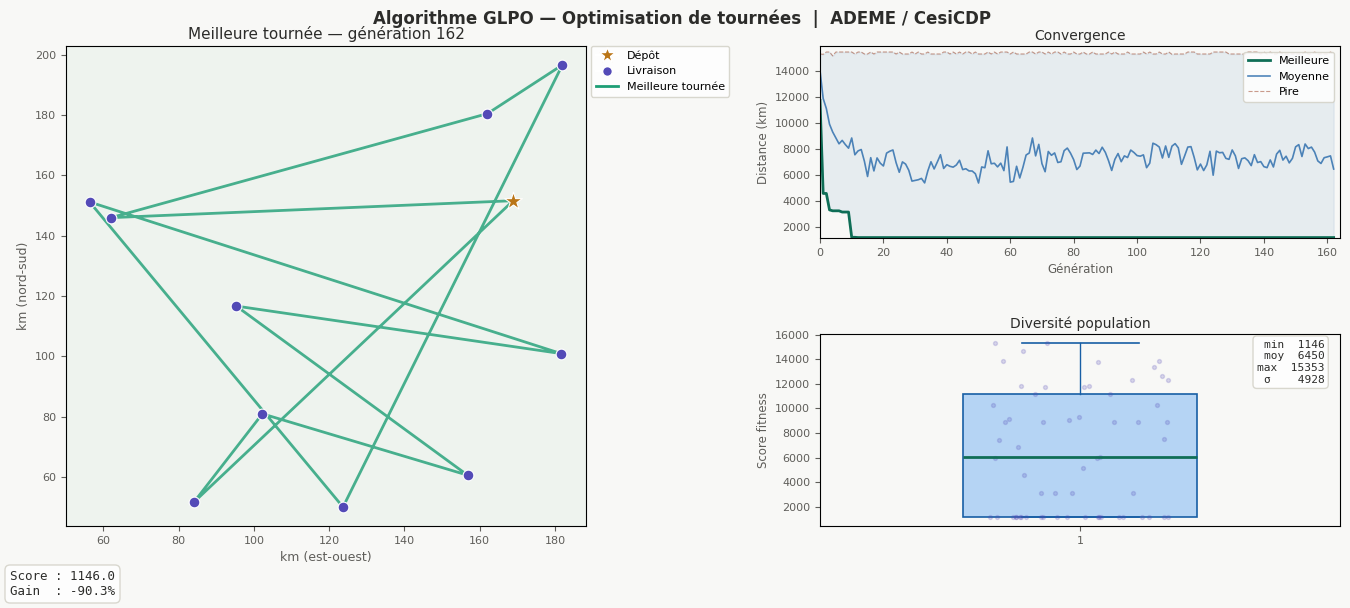


Tournée optimale : Dépôt → Ville 1 → Ville 2 → Ville 3 → Ville 4 → Ville 5 → Ville 6 → Ville 7 → Ville 8 → Ville 9 → Ville 10 → Dépôt
Score final      : 1145.9667


In [10]:
# ── Chargement de l'instance ──────────────────────────────────────────────────
CHEMIN_JSON = "datasets/tsptwd_n20.json"   # ← modifiez si besoin

instance = charger_instance(CHEMIN_JSON)

print(f"Instance chargée : {instance['n']} clients")
print(f"Horizon          : {instance['horizon']} min")
print(f"Perturbations    : {len(instance['perturbations'])}")
print()

# ── Conversion vers le format GLOP ────────────────────────────────────────────
villes, perturbations_glop = instance_vers_glop(instance)

# ── Lancement de GLOP ─────────────────────────────────────────────────────────
meilleur, score = lancer_visualisation(
    villes          = villes,
    perturbations   = perturbations_glop,
    taille_pop      = 60,
    n_generations   = 1000,
    taux_croisement = 0.85,
    taux_mutation   = 0.15,
    taux_elitisme   = 0.10,
    patience        = 150,
    dp_window       = 4,
    seed            = 42,
)

print()
print("Tournée optimale :", " → ".join(villes[i].nom for i in [0] + meilleur + [0]))
print(f"Score final      : {score:.4f}")


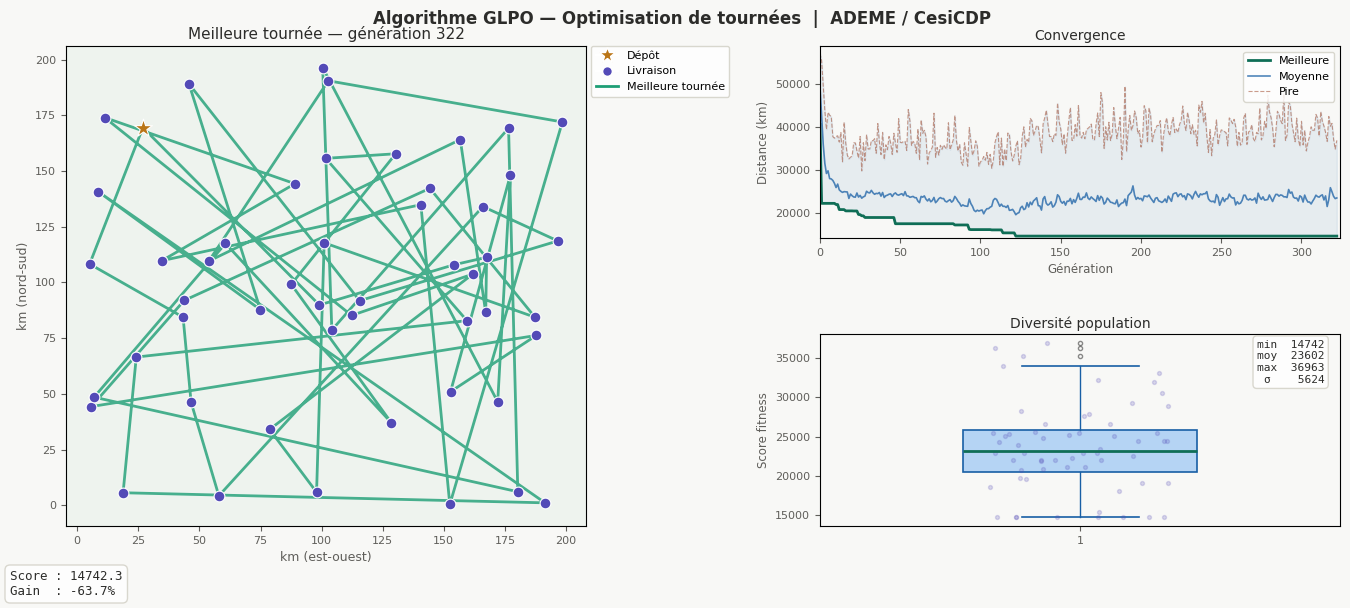


Tournée optimale : Dépôt → Ville 10 → Ville 12 → Ville 15 → Ville 17 → Ville 24 → Ville 37 → Ville 43 → Ville 8 → Ville 32 → Ville 36 → Ville 45 → Ville 4 → Ville 21 → Ville 29 → Ville 33 → Ville 3 → Ville 14 → Ville 19 → Ville 25 → Ville 28 → Ville 9 → Ville 26 → Ville 34 → Ville 39 → Ville 41 → Ville 47 → Ville 1 → Ville 11 → Ville 13 → Ville 16 → Ville 22 → Ville 23 → Ville 27 → Ville 35 → Ville 38 → Ville 48 → Ville 49 → Ville 50 → Ville 7 → Ville 30 → Ville 31 → Ville 6 → Ville 20 → Ville 42 → Ville 44 → Ville 46 → Ville 5 → Ville 18 → Ville 40 → Ville 2 → Dépôt
Score final      : 14742.2673


In [11]:
CHEMIN_JSON = "datasets/tsptwd_n50.json"   # ← modifiez si besoin

instance = charger_instance(CHEMIN_JSON)

print(f"Instance chargée : {instance['n']} clients")
print(f"Horizon          : {instance['horizon']} min")
print(f"Perturbations    : {len(instance['perturbations'])}")
print()

# ── Conversion vers le format GLOP ────────────────────────────────────────────
villes, perturbations_glop = instance_vers_glop(instance)

# ── Lancement de GLOP ─────────────────────────────────────────────────────────
meilleur, score = lancer_visualisation(
    villes          = villes,
    perturbations   = perturbations_glop,
    taille_pop      = 60,
    n_generations   = 1000,
    taux_croisement = 0.85,
    taux_mutation   = 0.15,
    taux_elitisme   = 0.10,
    patience        = 200,
    dp_window       = 4,
    seed            = 42,
)

print()
print("Tournée optimale :", " → ".join(villes[i].nom for i in [0] + meilleur + [0]))
print(f"Score final      : {score:.4f}")


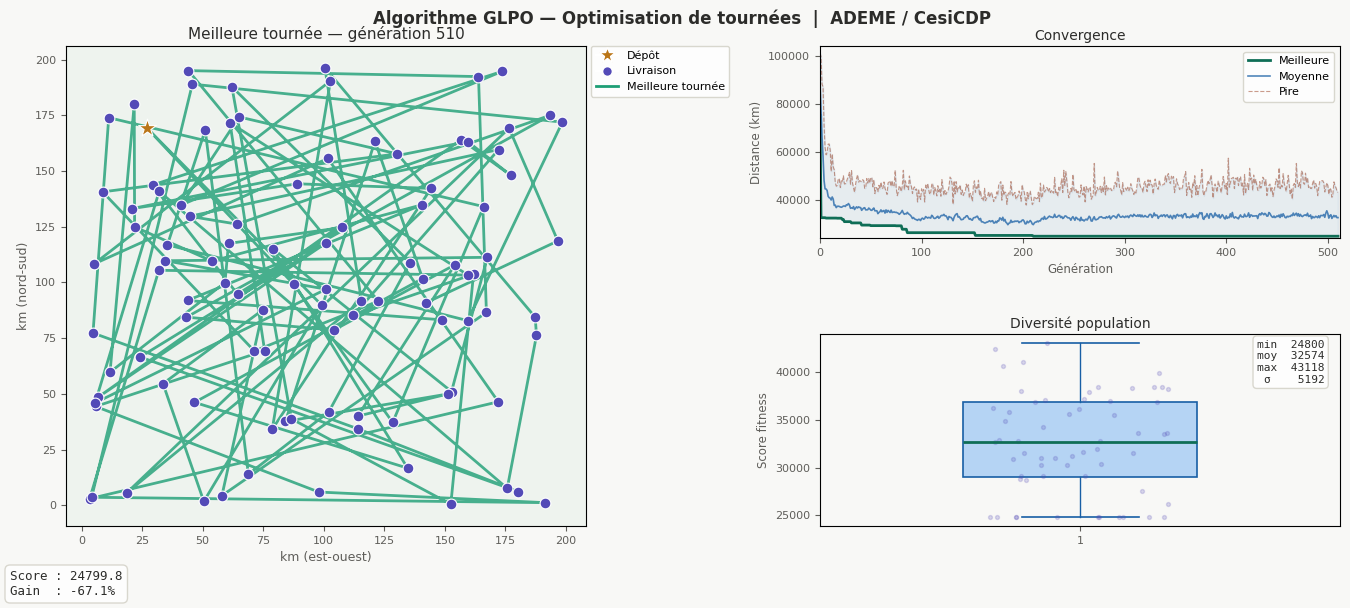


Tournée optimale : Dépôt → Ville 14 → Ville 19 → Ville 24 → Ville 50 → Ville 70 → Ville 92 → Ville 9 → Ville 21 → Ville 27 → Ville 28 → Ville 46 → Ville 47 → Ville 59 → Ville 98 → Ville 7 → Ville 22 → Ville 38 → Ville 42 → Ville 10 → Ville 33 → Ville 41 → Ville 62 → Ville 66 → Ville 80 → Ville 86 → Ville 95 → Ville 13 → Ville 35 → Ville 45 → Ville 75 → Ville 8 → Ville 20 → Ville 29 → Ville 57 → Ville 60 → Ville 65 → Ville 73 → Ville 78 → Ville 87 → Ville 97 → Ville 6 → Ville 48 → Ville 49 → Ville 58 → Ville 81 → Ville 83 → Ville 85 → Ville 12 → Ville 34 → Ville 40 → Ville 51 → Ville 63 → Ville 71 → Ville 74 → Ville 94 → Ville 15 → Ville 61 → Ville 82 → Ville 1 → Ville 18 → Ville 30 → Ville 52 → Ville 56 → Ville 77 → Ville 90 → Ville 11 → Ville 23 → Ville 39 → Ville 43 → Ville 4 → Ville 26 → Ville 37 → Ville 68 → Ville 88 → Ville 16 → Ville 31 → Ville 44 → Ville 64 → Ville 72 → Ville 84 → Ville 99 → Ville 25 → Ville 54 → Ville 69 → Ville 76 → Ville 93 → Ville 96 → Ville 100 → Ville 3 →

In [12]:
CHEMIN_JSON = "datasets/tsptwd_n100.json"   # ← modifiez si besoin

instance = charger_instance(CHEMIN_JSON)

print(f"Instance chargée : {instance['n']} clients")
print(f"Horizon          : {instance['horizon']} min")
print(f"Perturbations    : {len(instance['perturbations'])}")
print()

# ── Conversion vers le format GLOP ────────────────────────────────────────────
villes, perturbations_glop = instance_vers_glop(instance)

# ── Lancement de GLOP ─────────────────────────────────────────────────────────
meilleur, score = lancer_visualisation(
    villes          = villes,
    perturbations   = perturbations_glop,
    taille_pop      = 60,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.15,
    taux_elitisme   = 0.10,
    patience        = 300,
    dp_window       = 4,
    seed            = 42,
)

print()
print("Tournée optimale :", " → ".join(villes[i].nom for i in [0] + meilleur + [0]))
print(f"Score final      : {score:.4f}")


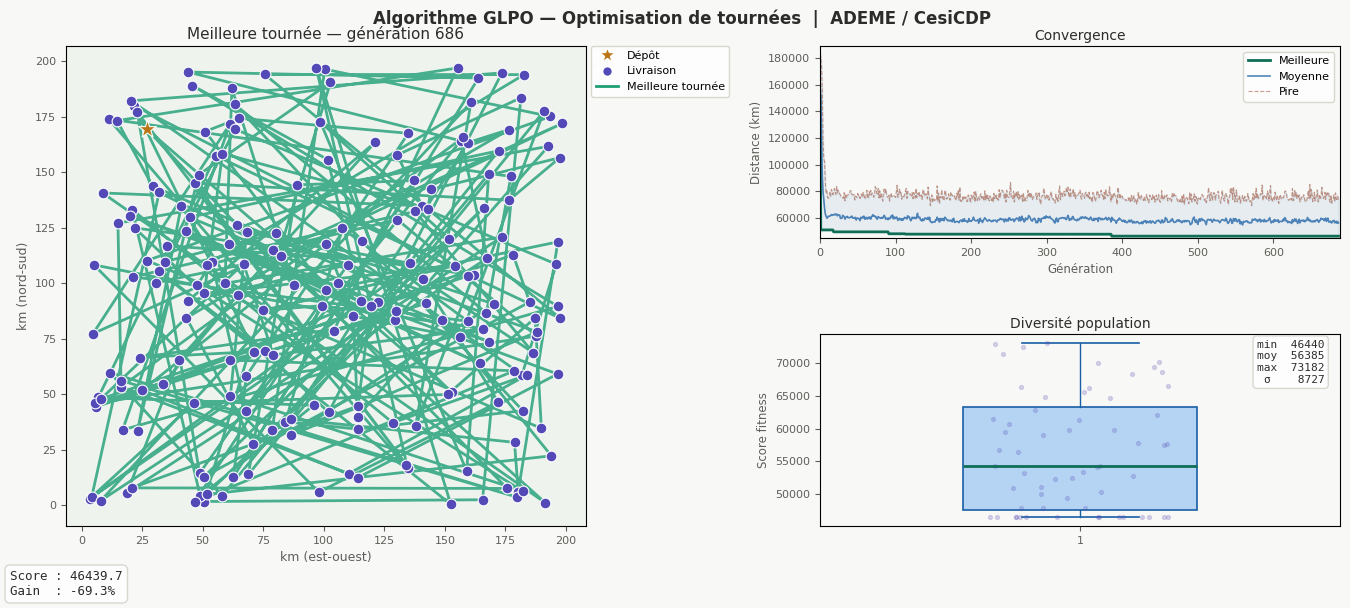


Tournée optimale : Dépôt → Ville 14 → Ville 87 → Ville 99 → Ville 115 → Ville 140 → Ville 176 → Ville 178 → Ville 48 → Ville 64 → Ville 73 → Ville 93 → Ville 135 → Ville 137 → Ville 147 → Ville 156 → Ville 166 → Ville 199 → Ville 20 → Ville 70 → Ville 86 → Ville 110 → Ville 152 → Ville 8 → Ville 33 → Ville 43 → Ville 67 → Ville 69 → Ville 96 → Ville 133 → Ville 134 → Ville 42 → Ville 89 → Ville 128 → Ville 200 → Ville 3 → Ville 31 → Ville 36 → Ville 45 → Ville 83 → Ville 154 → Ville 179 → Ville 184 → Ville 192 → Ville 30 → Ville 57 → Ville 78 → Ville 121 → Ville 150 → Ville 174 → Ville 197 → Ville 44 → Ville 104 → Ville 120 → Ville 124 → Ville 162 → Ville 172 → Ville 19 → Ville 98 → Ville 160 → Ville 198 → Ville 28 → Ville 127 → Ville 132 → Ville 136 → Ville 144 → Ville 149 → Ville 153 → Ville 11 → Ville 56 → Ville 68 → Ville 76 → Ville 119 → Ville 169 → Ville 34 → Ville 75 → Ville 77 → Ville 82 → Ville 90 → Ville 118 → Ville 123 → Ville 142 → Ville 146 → Ville 170 → Ville 25 → Ville 

In [13]:
CHEMIN_JSON = "datasets/tsptwd_n200.json"   # ← modifiez si besoin

instance = charger_instance(CHEMIN_JSON)

print(f"Instance chargée : {instance['n']} clients")
print(f"Horizon          : {instance['horizon']} min")
print(f"Perturbations    : {len(instance['perturbations'])}")
print()

# ── Conversion vers le format GLOP ────────────────────────────────────────────
villes, perturbations_glop = instance_vers_glop(instance)

# ── Lancement de GLOP ─────────────────────────────────────────────────────────
meilleur, score = lancer_visualisation(
    villes          = villes,
    perturbations   = perturbations_glop,
    taille_pop      = 60,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.15,
    taux_elitisme   = 0.10,
    patience        = 300,
    dp_window       = 4,
    seed            = 42,
)

print()
print("Tournée optimale :", " → ".join(villes[i].nom for i in [0] + meilleur + [0]))
print(f"Score final      : {score:.4f}")


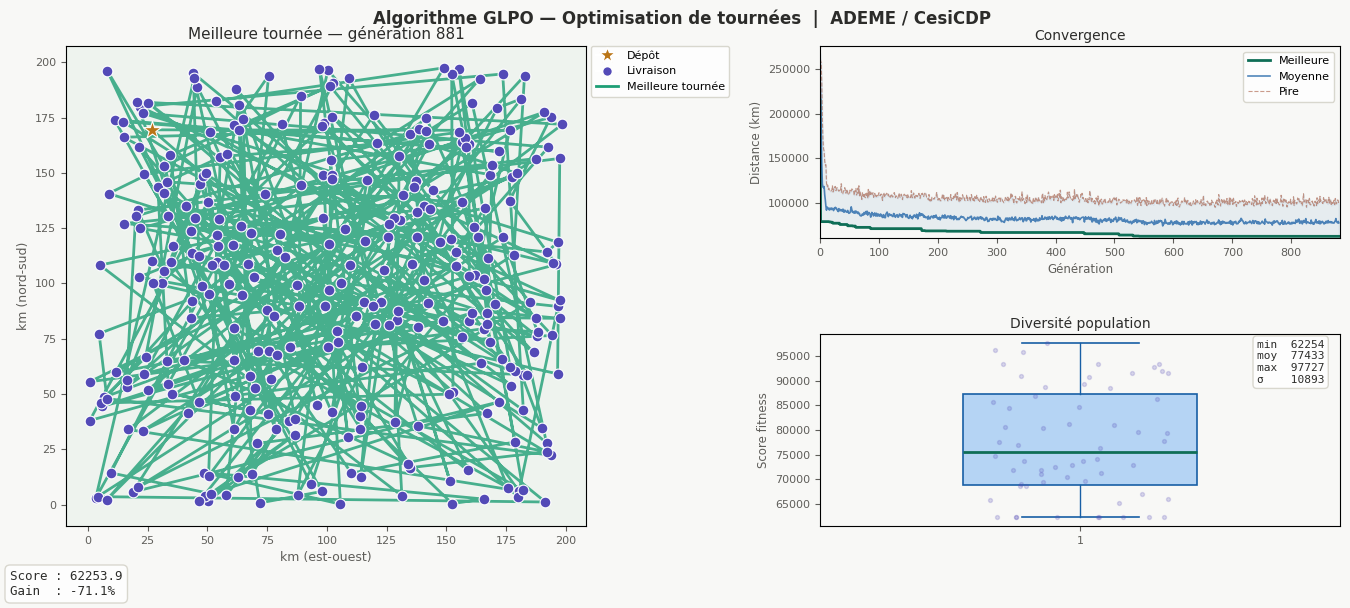


Tournée optimale : Dépôt → Ville 26 → Ville 48 → Ville 86 → Ville 136 → Ville 17 → Ville 78 → Ville 88 → Ville 95 → Ville 162 → Ville 173 → Ville 218 → Ville 278 → Ville 16 → Ville 56 → Ville 63 → Ville 99 → Ville 167 → Ville 187 → Ville 9 → Ville 110 → Ville 148 → Ville 172 → Ville 226 → Ville 272 → Ville 276 → Ville 295 → Ville 45 → Ville 75 → Ville 115 → Ville 154 → Ville 191 → Ville 257 → Ville 269 → Ville 294 → Ville 65 → Ville 156 → Ville 177 → Ville 198 → Ville 207 → Ville 243 → Ville 288 → Ville 292 → Ville 4 → Ville 41 → Ville 160 → Ville 186 → Ville 202 → Ville 223 → Ville 252 → Ville 268 → Ville 291 → Ville 13 → Ville 34 → Ville 84 → Ville 116 → Ville 146 → Ville 180 → Ville 285 → Ville 297 → Ville 12 → Ville 55 → Ville 117 → Ville 123 → Ville 199 → Ville 8 → Ville 21 → Ville 28 → Ville 40 → Ville 83 → Ville 96 → Ville 101 → Ville 152 → Ville 194 → Ville 274 → Ville 7 → Ville 25 → Ville 64 → Ville 85 → Ville 107 → Ville 147 → Ville 230 → Ville 267 → Ville 2 → Ville 20 → Vil

In [14]:
CHEMIN_JSON = "datasets/tsptwd_n300.json"   # ← modifiez si besoin

instance = charger_instance(CHEMIN_JSON)

print(f"Instance chargée : {instance['n']} clients")
print(f"Horizon          : {instance['horizon']} min")
print(f"Perturbations    : {len(instance['perturbations'])}")
print()

# ── Conversion vers le format GLOP ────────────────────────────────────────────
villes, perturbations_glop = instance_vers_glop(instance)

# ── Lancement de GLOP ─────────────────────────────────────────────────────────
meilleur, score = lancer_visualisation(
    villes          = villes,
    perturbations   = perturbations_glop,
    taille_pop      = 60,
    n_generations   = 10000,
    taux_croisement = 0.85,
    taux_mutation   = 0.15,
    taux_elitisme   = 0.10,
    patience        = 300,
    dp_window       = 4,
    seed            = 42,
)

print()
print("Tournée optimale :", " → ".join(villes[i].nom for i in [0] + meilleur + [0]))
print(f"Score final      : {score:.4f}")
